In [1]:
from google.colab import files

uploaded = files.upload()


Saving Face_Recognition_Dataset.zip to Face_Recognition_Dataset.zip


In [2]:
import zipfile

zip_filename = 'Face_Recognition_Dataset.zip'  # use the same name you see after upload

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/')

# Check what got extracted
!ls /content


Face_Recognition_Dataset.zip  images  sample_data


In [4]:
!ls /content/images
!ls /content/images/train
!ls /content/images/validation


images	train  validation
angry  disgust	fear  happy  neutral  sad  surprise
angry  disgust	fear  happy  neutral  sad  surprise


In [5]:
train_dir = '/content/images/train'
val_dir = '/content/images/validation'

In [6]:
# Your structure is: /content/Images/train and /content/Images/validation
import os
train_dir = '/content/images/train'
val_dir = '/content/images/validation'

# Check folders
print("Train folders:", os.listdir(train_dir))
print("Validation folders:", os.listdir(val_dir))

Train folders: ['angry', 'happy', 'fear', 'disgust', 'neutral', 'sad', 'surprise']
Validation folders: ['angry', 'happy', 'fear', 'disgust', 'neutral', 'sad', 'surprise']


In [7]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

In [8]:
IMG_HEIGHT, IMG_WIDTH = 48, 48
BATCH_SIZE = 64

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    val_dir,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    color_mode='grayscale',
    class_mode='categorical'
)


Found 28821 images belonging to 7 classes.
Found 7066 images belonging to 7 classes.


In [9]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    loss='categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 46, 46, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 44, 44, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 22, 22, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 5184)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       663,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 729,575 (2.78 MB)

 Trainable params: 729,575 (2.78 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
EPOCHS = 30

history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator
)


Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


451/451 ━━━━━━━━━━━━━━━━━━━━ 36s 62ms/step - accuracy: 0.2401 - loss: 1.8211 - val_accuracy: 0.3623 - val_loss: 1.6578
Epoch 2/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.3214 - loss: 1.6966 - val_accuracy: 0.4271 - val_loss: 1.5050
Epoch 3/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 21s 46ms/step - accuracy: 0.3810 - loss: 1.5800 - val_accuracy: 0.4583 - val_loss: 1.4123
Epoch 4/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.4127 - loss: 1.5098 - val_accuracy: 0.4955 - val_loss: 1.3138
Epoch 5/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.4383 - loss: 1.4557 - val_accuracy: 0.5062 - val_loss: 1.2847
Epoch 6/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 22s 48ms/step - accuracy: 0.4549 - loss: 1.4127 - val_accuracy: 0.5161 - val_loss: 1.2500
Epoch 7/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.4704 - loss: 1.3847 - val_accuracy: 0.5379 - val_loss: 1.2059
Epoch 8/30
451/451 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.4704 - loss: 1.3665 - val_accurac

In [11]:
model.save('FER_model.h5')
print("Model saved as FER_model.h5")

Model saved as FER_model.h5


Saving 345.jpg to 345.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Predicted Emotion: surprise


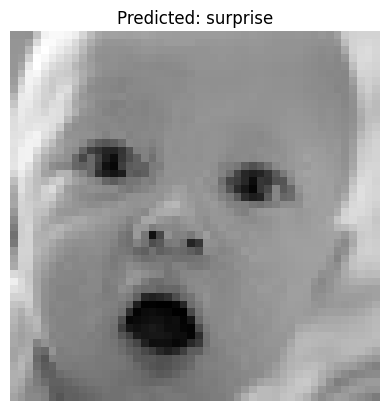

In [37]:
from tensorflow.keras.preprocessing import image

# Upload an image
uploaded = files.upload()

# Use uploaded file
img_path = list(uploaded.keys())[0]

# Preprocess
img = image.load_img(img_path, target_size=(IMG_HEIGHT, IMG_WIDTH), color_mode='grayscale')
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0) / 255.0

# Predict
prediction = model.predict(img_array)
predicted_class = np.argmax(prediction)
class_labels = list(train_generator.class_indices.keys())

print("Predicted Emotion:", class_labels[predicted_class])

plt.imshow(img, cmap='gray')
plt.title(f"Predicted: {class_labels[predicted_class]}")
plt.axis('off')
plt.show()
